<a href="https://colab.research.google.com/github/harunsezer/ML-Lecture/blob/machine_learning/titanic_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import os

for dirname, _, filenames in os.walk('/content/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/kaggle/input/gender_submission (1).csv
/content/kaggle/input/test (1).csv
/content/kaggle/input/titanic/train (1).csv


In [12]:
train_data = pd.read_csv("/content/kaggle/input/titanic/train .csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
test_data = pd.read_csv("/content/kaggle/input/titanic/test .csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [16]:
women = train_data.loc[train_data.Sex == 'female']["Survived"]
rate_women = sum(women)/len(women)

print("% of women who survived:", rate_women)

% of women who survived: 0.7420382165605095


In [17]:
men = train_data.loc[train_data.Sex == 'male']["Survived"]
rate_men = sum(men)/len(men)

print("% of men who survived:", rate_men)

% of men who survived: 0.18890814558058924


In [18]:
from sklearn.ensemble import RandomForestClassifier

y = train_data["Survived"]

features = ["Pclass", "Sex", "SibSp", "Parch"]
X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X, y)
predictions = model.predict(X_test)

output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [21]:
rf_predictions = pd.read_csv('/content/submission.csv')
rf_predictions.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [22]:
sgd_predictions = pd.read_csv('/content/sgd_submission.csv')
sgd_predictions.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [23]:
rf_survived_counts = rf_predictions['Survived'].value_counts()
print("Random Forest 'Survived' Predictions Distribution:")
print(rf_survived_counts)

Random Forest 'Survived' Predictions Distribution:
Survived
0    270
1    148
Name: count, dtype: int64


In [24]:
sgd_survived_counts = sgd_predictions['Survived'].value_counts()
print("SGDClassifier 'Survived' Predictions Distribution:")
print(sgd_survived_counts)

SGDClassifier 'Survived' Predictions Distribution:
Survived
0    237
1    181
Name: count, dtype: int64


In [28]:
comparison_df = pd.merge(rf_predictions, sgd_predictions, on='PassengerId', suffixes=('_rf', '_sgd'))
comparison_df.head()

,PassengerId,Survived_rf,Survived_sgd
0,892,0,0
1,893,1,1
2,894,0,0
3,895,0,0
4,896,1,1


In [26]:
discrepancies_df = comparison_df[comparison_df['Survived_rf'] != comparison_df['Survived_sgd']]
num_discrepancies = len(discrepancies_df)
print(f"Number of passengers with differing predictions: {num_discrepancies}")

Number of passengers with differing predictions: 41


In [29]:
print("First 5 discrepancies between Random Forest and SGDClassifier predictions:")
discrepancies_df.head()

First 5 discrepancies between Random Forest and SGDClassifier predictions:


,PassengerId,Survived_rf,Survived_sgd
11,903,0,1
28,920,0,1
32,924,0,1
33,925,0,1
41,933,0,1


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Eğitim verilerini eğitim ve doğrulama setlerine ayırma
# X ve y daha önce pd.get_dummies(train_data[features]) ve train_data["Survived"] olarak tanımlanmıştı.
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim seti boyutu: {len(X_train_split)}")
print(f"Doğrulama seti boyutu: {len(X_val_split)}")

Eğitim seti boyutu: 712
Doğrulama seti boyutu: 179


In [37]:
# Random Forest modelini yeni eğitim setinde eğitme
model_rf_pr = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model_rf_pr.fit(X_train_split, y_train_split)

# SGDClassifier modelini yeni eğitim setinde eğitme
sgd_model_pr = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=1)
sgd_model_pr.fit(X_train_split, y_train_split)

# Random Forest için tahmin olasılıklarını alma
y_scores_rf = model_rf_pr.predict_proba(X_val_split)[:, 1]

# SGDClassifier için karar fonksiyonu skorlarını alma
y_scores_sgd = sgd_model_pr.decision_function(X_val_split)

print("Modeller başarıyla eğitildi ve tahmin skorları alındı.")

Modeller başarıyla eğitildi ve tahmin skorları alındı.


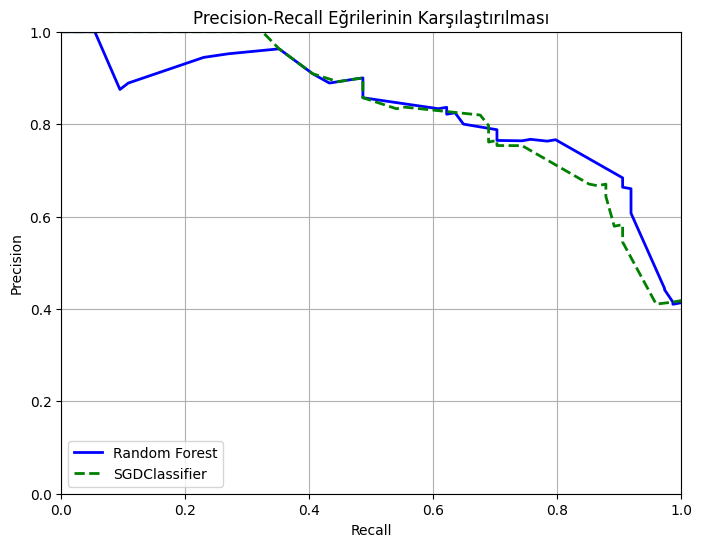

In [38]:
# Random Forest için Precision-Recall eğrisini hesaplama
precisions_rf, recalls_rf, thresholds_rf = precision_recall_curve(y_val_split, y_scores_rf)

# SGDClassifier için Precision-Recall eğrisini hesaplama
precisions_sgd, recalls_sgd, thresholds_sgd = precision_recall_curve(y_val_split, y_scores_sgd)

plt.figure(figsize=(8, 6))

plt.plot(recalls_rf, precisions_rf, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls_sgd, precisions_sgd, "g--", linewidth=2, label="SGDClassifier")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid(True)
plt.legend(loc="lower left")
plt.title("Precision-Recall Eğrilerinin Karşılaştırılması")

plt.show()